In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from prettytable import PrettyTable
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Embedding, Flatten, Concatenate, Conv1D, Reshape, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
!pip install keras-tuner -q
import keras_tuner as kt
import time
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/games_metadata.json
/kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/users.csv
/kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/games.csv
/kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/recommendations.csv


## Câu 1: Phân tích khám phá dữ liệu (EDA)
- Load dữ liệu từ các file CSV.
- Kiểm tra thông tin tổng quan, giá trị khuyết thiếu.
- Trực quan hóa phân bố của nhãn (Label - `is_recommended`).

========== THÔNG TIN TỔNG QUAN: GAMES.CSV ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          50872 non-null  int64  
 1   title           50872 non-null  object 
 2   date_release    50872 non-null  object 
 3   win             50872 non-null  bool   
 4   mac             50872 non-null  bool   
 5   linux           50872 non-null  bool   
 6   rating          50872 non-null  object 
 7   positive_ratio  50872 non-null  int64  
 8   user_reviews    50872 non-null  int64  
 9   price_final     50872 non-null  float64
 10  price_original  50872 non-null  float64
 11  discount        50872 non-null  float64
 12  steam_deck      50872 non-null  bool   
dtypes: bool(4), float64(3), int64(3), object(3)
memory usage: 3.7+ MB
None
--------------------------------------------------
Số lượng giá trị khuyết thiếu (Missi

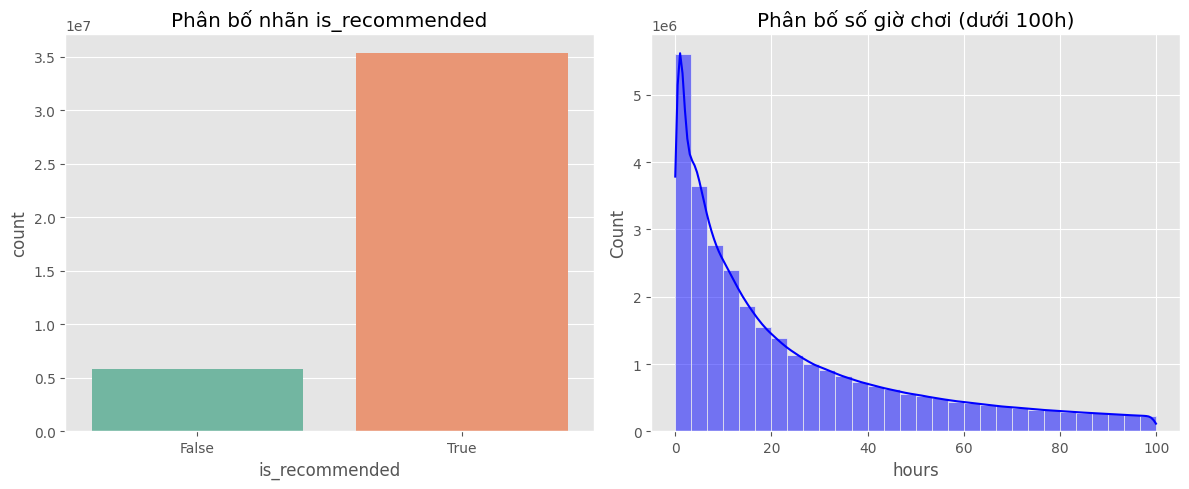

In [8]:
def perform_eda(df, dataset_name="Dataset"):
    print(f"========== THÔNG TIN TỔNG QUAN: {dataset_name} ==========")
    print(df.info())
    print("-" * 50)
    print("Số lượng giá trị khuyết thiếu (Missing values):")
    print(df.isnull().sum())
    print("=" * 50 + "\n")

games_df = pd.read_csv('/kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/games.csv')
recs_df = pd.read_csv('/kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/recommendations.csv')

perform_eda(games_df, "GAMES.CSV")
perform_eda(recs_df, "RECOMMENDATIONS.CSV")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=recs_df, x='is_recommended', palette='Set2')
plt.title('Phân bố nhãn is_recommended')

plt.subplot(1, 2, 2)
sns.histplot(recs_df[recs_df['hours'] < 100]['hours'], bins=30, kde=True, color='blue')
plt.title('Phân bố số giờ chơi (dưới 100h)')
plt.tight_layout()
plt.show()

## Câu 2: Tiền xử lý dữ liệu (Data Preprocessing)
- Lấy mẫu (Sampling) 10% dữ liệu để tránh tràn RAM (theo gợi ý đề bài).
- Bỏ các cột thiếu nhiều dữ liệu (`discount`, `price_final`), điền khuyết `price_original`.
- Nối bảng (Merge) recommendations và games.
- Label Encoding: Chuyển `user_id`, `app_id` thành index liên tục (BẮT BUỘC cho lớp Embedding của NCF, MLP, CNN).
- **Lưu ý (đã sửa so với bản đầu):** KHÔNG chuẩn hóa (StandardScaler) `hours`/`price_original` ở bước này nữa.
  Việc chuẩn hóa được dời sang SAU khi chia Train/Validation/Test (ở Câu 4) và chỉ `fit` trên tập Train, nhằm
  tránh rò rỉ dữ liệu (data leakage) từ Validation/Test vào bước tiền xử lý.


In [9]:
def preprocess_steam_data(games, recs, sample_frac=0.02):
    if len(recs) > 1000000:
        recs = recs.sample(frac=sample_frac, random_state=42).reset_index(drop=True)
        print(f"Đã lấy mẫu {sample_frac*100}% dữ liệu recommendations. Kích thước mới: {recs.shape}")

    games = games.drop(columns=['discount', 'price_final'], errors='ignore')
    games['price_original'] = games['price_original'].fillna(0)
    df_merged = recs.merge(games, on='app_id', how='inner')

    user_encoder = LabelEncoder()
    app_encoder = LabelEncoder()
    df_merged['user_encoded'] = user_encoder.fit_transform(df_merged['user_id'])
    df_merged['app_encoded'] = app_encoder.fit_transform(df_merged['app_id'])
    num_users = df_merged['user_encoded'].nunique()
    num_items = df_merged['app_encoded'].nunique()
    print(f"Số lượng Unique Users: {num_users}, Unique Games: {num_items}")
    df_merged['label'] = df_merged['is_recommended'].astype(int)

    cols_to_fill = ['win', 'mac', 'linux', 'steam_deck']
    for col in cols_to_fill:
        if col in df_merged.columns:
            df_merged[col] = df_merged[col].fillna(False).astype(int)

    print("Tiền xử lý hoàn tất!")
    return df_merged, num_users, num_items, user_encoder, app_encoder

df_processed, NUM_USERS, NUM_ITEMS, user_encoder, app_encoder = preprocess_steam_data(games_df, recs_df, sample_frac=0.1)
display(df_processed[['user_encoded', 'app_encoded', 'hours', 'price_original', 'win', 'label']].head())


Đã lấy mẫu 10.0% dữ liệu recommendations. Kích thước mới: (4115479, 8)
Số lượng Unique Users: 2917332, Unique Games: 32017
Tiền xử lý hoàn tất!


,user_encoded,app_encoded,hours,price_original,win,label
0,1546426,3019,1.4,0.00,1,1
1,2332483,3327,27.0,19.99,1,1
2,2077198,6218,9.8,19.99,1,1
3,1067624,1970,2.2,9.99,1,1
4,2550347,1177,17.1,0.00,1,1


## Câu 3: Lựa chọn đặc trưng (Feature Selection)
- Sử dụng **RandomForestClassifier** để tính toán mức độ quan trọng của các đặc trưng (Feature Importances) đối với dữ liệu dạng bảng.
- **Lý do lựa chọn:** Random Forest xử lý rất tốt các biến hỗn hợp (vừa có số thực như `hours`, vừa có boolean như `win`, `mac`) và không yêu cầu chuẩn hóa khắt khe. Nó cung cấp chỉ số quan trọng rõ ràng để ta loại bỏ các cột gây nhiễu.
- Đối với mạng NCF, đặc trưng chính là các vector ẩn (Embeddings) được tự động học từ `user_encoded` và `app_encoded`.

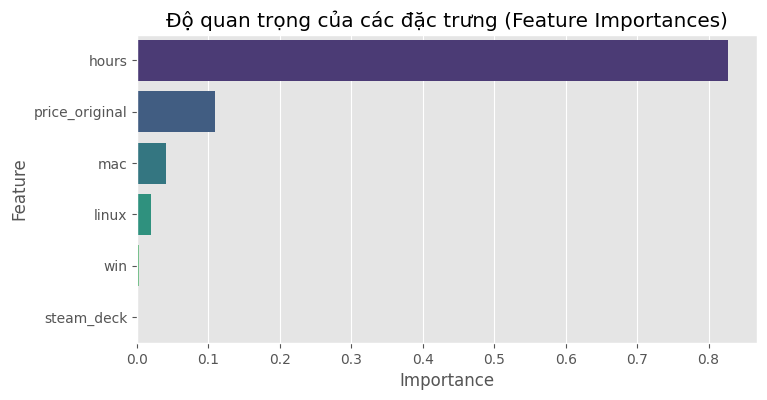

          Feature  Importance
0           hours    0.826465
1  price_original    0.109643
3             mac    0.040480
4           linux    0.020047
2             win    0.003115
5      steam_deck    0.000249


In [10]:
def feature_selection_rf(df, target_col, feature_cols):
    X = df[feature_cols]
    y = df[target_col]
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    
    importances = rf.feature_importances_
    feature_importances = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
    plt.title("Độ quan trọng của các đặc trưng (Feature Importances)")
    plt.show()
    
    return feature_importances

tabular_features = ['hours', 'price_original', 'win', 'mac', 'linux', 'steam_deck']
important_features = feature_selection_rf(df_processed, 'label', tabular_features)
print(important_features)

## Câu 4: Huấn luyện và đánh giá mô hình (Train & Evaluate Models)
- **Chia dữ liệu:** Train (64%) / Validation (16%) / Test (20%) — có thêm tập Validation riêng so với bản đầu
  (chỉ Train/Test 80/20), dùng để dò ngưỡng phân loại ở Câu 5 mà không chạm vào tập Test.
- **Chuẩn hóa (StandardScaler):** chỉ `fit` trên tập Train, sau đó `transform` Validation/Test bằng đúng thống
  kê đó — tránh rò rỉ dữ liệu.
- **Đặc trưng dạng bảng:** giảm còn `['hours', 'price_original', 'mac', 'linux']` — loại bỏ `win` và
  `steam_deck` vì kết quả Feature Importance ở Câu 3 cho thấy hai cờ này đóng góp dưới 0.2% (gần như nhiễu).
- **Xây dựng 5 mô hình Baseline:**
  1. K-Nearest Neighbors (dùng `metric='cosine'` để đại diện cho thuật toán Cosine Similarity).
  2. Random Forest Classifier.
  3. Mạng Nơ-ron truyền thống: MLP (Multilayer Perceptron) và CNN 1D.
  4. Mạng Nơ-ron gợi ý chuyên dụng: NCF (Neural Collaborative Filtering) — **giữ nguyên kiến trúc chỉ dùng
     Embedding(user_id, item_id)**, không nạp thêm đặc trưng bảng, vì `hours` (đặc trưng quan trọng nhất) chỉ
     tồn tại SAU khi người dùng đã chơi — không có sẵn cho các game ứng viên chưa từng chơi khi gợi ý thực tế.
     Đây cũng là lý do NCF là mô hình duy nhất được tích hợp suy luận thật vào `app.py`.
- **Đánh giá:** bổ sung AUC-ROC cho cả 5 mô hình (không chỉ 3 mô hình DL như bản đầu) để so sánh nhất quán.


In [11]:
print("ĐANG XỬ LÝ CÂN BẰNG DỮ LIỆU (UNDERSAMPLING)...")

df_label_0 = df_processed[df_processed['label'] == 0]
df_label_1 = df_processed[df_processed['label'] == 1]
print(f"Trước cân bằng -> Nhãn 0: {len(df_label_0)} mẫu, Nhãn 1: {len(df_label_1)} mẫu")

df_label_1_downsampled = df_label_1.sample(n=len(df_label_0), random_state=42)
df_balanced = pd.concat([df_label_0, df_label_1_downsampled]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Sau cân bằng  -> Nhãn 0: {len(df_balanced[df_balanced['label']==0])} mẫu, Nhãn 1: {len(df_balanced[df_balanced['label']==1])} mẫu\n")

tabular_features = ['hours', 'price_original', 'mac', 'linux']

X_all = df_balanced[['user_encoded', 'app_encoded'] + tabular_features]
y_all = df_balanced['label']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

scaler = StandardScaler()
X_train_tab = pd.DataFrame(scaler.fit_transform(X_train[tabular_features]), columns=tabular_features, index=X_train.index)
X_val_tab = pd.DataFrame(scaler.transform(X_val[tabular_features]), columns=tabular_features, index=X_val.index)
X_test_tab = pd.DataFrame(scaler.transform(X_test[tabular_features]), columns=tabular_features, index=X_test.index)

X_train_user = X_train['user_encoded'].values
X_train_item = X_train['app_encoded'].values
X_val_user = X_val['user_encoded'].values
X_val_item = X_val['app_encoded'].values
X_test_user = X_test['user_encoded'].values
X_test_item = X_test['app_encoded'].values

print(f"Chia tập Train ({len(X_train)}) / Validation ({len(X_val)}) / Test ({len(X_test)}) thành công!")


ĐANG XỬ LÝ CÂN BẰNG DỮ LIỆU (UNDERSAMPLING)...
Trước cân bằng -> Nhãn 0: 585142 mẫu, Nhãn 1: 3530337 mẫu
Sau cân bằng  -> Nhãn 0: 585142 mẫu, Nhãn 1: 585142 mẫu

Chia tập Train (748981) / Validation (187246) / Test (234057) thành công!


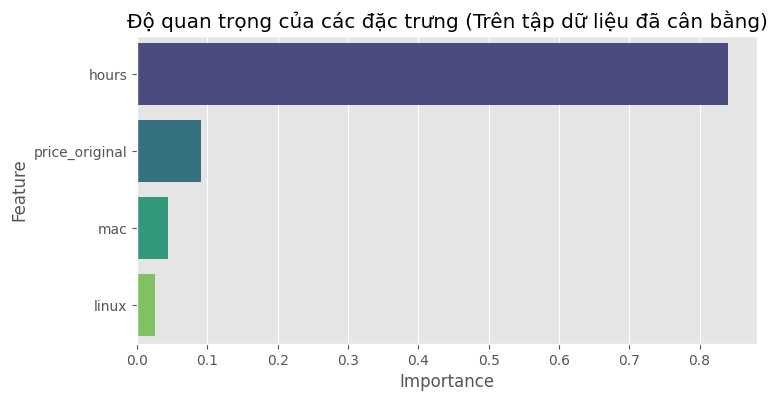

          Feature  Importance
0           hours    0.839707
1  price_original    0.090929
2             mac    0.043934
3           linux    0.025430


In [12]:
def feature_selection_rf(df, target_col, feature_cols):
    X = df[feature_cols]
    y = df[target_col]
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    
    importances = rf.feature_importances_
    feature_importances = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
    plt.title("Độ quan trọng của các đặc trưng (Trên tập dữ liệu đã cân bằng)")
    plt.show()
    return feature_importances

important_features = feature_selection_rf(df_balanced, 'label', tabular_features)
print(important_features)

In [13]:
def build_mlp(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn1d(input_dim):
    model = Sequential([
        Reshape((input_dim, 1), input_shape=(input_dim,)),
        Conv1D(32, kernel_size=3, activation='relu'),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_ncf(num_users, num_items, embed_dim=16):
    user_input = Input(shape=(1,), name='user_input')
    item_input = Input(shape=(1,), name='item_input')
    
    user_emb = Embedding(num_users, embed_dim)(user_input)
    item_emb = Embedding(num_items, embed_dim)(item_input)
    
    concat = Concatenate()([Flatten()(user_emb), Flatten()(item_emb)])
    dense1 = Dense(64, activation='relu')(concat)
    drop1 = Dropout(0.3)(dense1)
    dense2 = Dense(32, activation='relu')(drop1)
    drop2 = Dropout(0.2)(dense2)
    out = Dense(1, activation='sigmoid')(drop2)
    
    model = Model(inputs=[user_input, item_input], outputs=out)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

table = PrettyTable()
table.field_names = ["Mô hình", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
predictions = {}
probabilities = {}

print("Đang huấn luyện Cosine Similarity (kNN)...")
max_knn_train = min(20000, len(X_train_tab))
max_knn_test = min(2000, len(X_test_tab))
knn_cosine = KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
knn_cosine.fit(X_train_tab[:max_knn_train], y_train[:max_knn_train])

y_pred_knn = np.zeros(len(X_test_tab), dtype=int)
y_prob_knn = np.zeros(len(X_test_tab))
y_pred_knn[:max_knn_test] = knn_cosine.predict(X_test_tab[:max_knn_test])
y_prob_knn[:max_knn_test] = knn_cosine.predict_proba(X_test_tab[:max_knn_test])[:, 1]
predictions['Cosine (kNN)'] = y_pred_knn
probabilities['Cosine (kNN)'] = y_prob_knn

print("Đang huấn luyện Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tab, y_train)
predictions['Random Forest'] = rf_model.predict(X_test_tab)
probabilities['Random Forest'] = rf_model.predict_proba(X_test_tab)[:, 1]

print("Đang huấn luyện MLP...")
mlp_model = build_mlp(X_train_tab.shape[1])
mlp_model.fit(X_train_tab, y_train, validation_data=(X_val_tab, y_val), epochs=10, batch_size=256, callbacks=[early_stop], verbose=0)
prob_mlp = mlp_model.predict(X_test_tab, verbose=0).flatten()
predictions['MLP'] = (prob_mlp > 0.5).astype(int)
probabilities['MLP'] = prob_mlp

print("Đang huấn luyện CNN 1D...")
cnn_model = build_cnn1d(X_train_tab.shape[1])
cnn_model.fit(X_train_tab, y_train, validation_data=(X_val_tab, y_val), epochs=10, batch_size=256, callbacks=[early_stop], verbose=0)
prob_cnn = cnn_model.predict(X_test_tab, verbose=0).flatten()
predictions['CNN 1D'] = (prob_cnn > 0.5).astype(int)
probabilities['CNN 1D'] = prob_cnn

print("Đang huấn luyện NCF (Sẽ mất chút thời gian)...")
ncf_model = build_ncf(NUM_USERS, NUM_ITEMS)
ncf_model.fit([X_train_user, X_train_item], y_train, validation_data=([X_val_user, X_val_item], y_val), epochs=10, batch_size=512, callbacks=[early_stop], verbose=1)
prob_ncf = ncf_model.predict([X_test_user, X_test_item], verbose=0).flatten()
predictions['NCF'] = (prob_ncf > 0.5).astype(int)
probabilities['NCF'] = prob_ncf

for model_name, y_pred in predictions.items():
    if model_name == 'Cosine (kNN)':
        y_test_eval = y_test[:max_knn_test]
        y_pred_eval = y_pred[:max_knn_test]
        y_prob_eval = probabilities[model_name][:max_knn_test]
    else:
        y_test_eval = y_test
        y_pred_eval = y_pred
        y_prob_eval = probabilities[model_name]

    acc = accuracy_score(y_test_eval, y_pred_eval)
    prec = precision_score(y_test_eval, y_pred_eval, zero_division=0)
    rec = recall_score(y_test_eval, y_pred_eval, zero_division=0)
    f1 = f1_score(y_test_eval, y_pred_eval, zero_division=0)
    auc = roc_auc_score(y_test_eval, y_prob_eval)
    table.add_row([model_name, f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{auc:.4f}"])

print("\nKẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH (BASELINE - SAU KHI CÂN BẰNG):")
print(table)


Đang huấn luyện Cosine Similarity (kNN)...
Đang huấn luyện Random Forest...
Đang huấn luyện MLP...


I0000 00:00:1783523074.478157      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783523074.481067      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1783523079.197051     238 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.
Đang huấn luyện CNN 1D...
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.
Đang huấn luyện NCF (Sẽ mất chút thời gian)...
Epoch 1/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.6587 - loss: 0.6134 - val_accuracy: 0.6769 - val_loss: 0.5958
Epoch 2/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9040 - loss: 0.2682 - val_accuracy: 0.5985 - val_loss: 0.8286
Epoch 3/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9645 - loss: 0.1002 - val_accuracy: 0.6257 - val_loss: 0.7915
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.

KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH (BASELINE - SAU KHI CÂN BẰNG):
+---------------+----------+-----------+--------+----------+---------+
|    Mô hình    | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
+---------------+----------+-----------+--------+----------+---------+
|  Cosin

## Câu 5: Fine-tune (Tinh chỉnh siêu tham số)
- **Mục tiêu:** Tìm ra bộ siêu tham số (hyperparameters) tối ưu nhất để cải thiện hiệu suất của MLP, CNN 1D và NCF.
- **Thực hiện:**
  - Sử dụng thư viện **KerasTuner** (`BayesianOptimization`), tìm kiếm trên tập Train (50% mẫu để tăng tốc),
    đánh giá bằng tập **Validation** (không phải tách thêm từ Train như bản đầu).
  - Không gian tìm kiếm: Số lượng nơ-ron (units/filters), kích thước Embedding (cho NCF) và Tốc độ học.
- **Hiệu chỉnh ngưỡng phân loại (đã sửa so với bản đầu):** ngưỡng tối ưu (để đạt Precision mục tiêu) được dò
  **trên tập Validation**, sau đó áp đúng ngưỡng đó lên tập **Test hoàn toàn chưa được dùng để tinh chỉnh** khi
  báo cáo số liệu cuối cùng. Bản đầu dò ngưỡng và báo cáo kết quả trên cùng một tập Test — đây là một dạng rò
  rỉ dữ liệu (nhìn đáp án của tập test trước khi chấm) khiến số liệu có thể lạc quan hơn thực tế.
- **Đánh giá:** Lập bảng tổng hợp so sánh hiệu quả Trước và Sau khi Fine-tune.


In [15]:
print("========== BẮT ĐẦU FINE-TUNING CÁC MÔ HÌNH DEEP LEARNING ==========\n")
start_time_total = time.time()
tune_sample = int(0.50 * len(X_train_tab))

kt_early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr=1e-5, verbose=0)

def build_mlp_kt(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_1', 32, 128, step=32), activation='swish', input_dim=X_train_tab.shape[1]))
    model.add(Dropout(hp.Float('drop_1', 0.1, 0.5, step=0.1)))
    model.add(Dense(units=hp.Int('units_2', 16, 64, step=16), activation='swish'))
    model.add(Dropout(hp.Float('drop_2', 0.1, 0.4, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn1d_kt(hp):
    model = Sequential()
    model.add(Reshape((X_train_tab.shape[1], 1), input_shape=(X_train_tab.shape[1],)))
    model.add(Conv1D(filters=hp.Int('filters', 16, 64, step=16), kernel_size=3, activation='swish'))
    model.add(Flatten())
    model.add(Dense(units=hp.Int('units', 16, 64, step=16), activation='swish'))
    model.add(Dropout(hp.Float('drop', 0.1, 0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_ncf_kt(hp):
    user_input = Input(shape=(1,), name='user_input')
    item_input = Input(shape=(1,), name='item_input')
    embed_dim = hp.Int('embed_dim', 8, 32, step=8)
    user_emb = Embedding(NUM_USERS, embed_dim)(user_input)
    item_emb = Embedding(NUM_ITEMS, embed_dim)(item_input)
    concat = Concatenate()([Flatten()(user_emb), Flatten()(item_emb)])
    dense1 = Dense(units=hp.Int('units_1', 32, 128, step=32), activation='swish')(concat)
    drop1 = Dropout(hp.Float('drop_1', 0.1, 0.5, step=0.1))(dense1)
    dense2 = Dense(units=hp.Int('units_2', 16, 64, step=16), activation='swish')(drop1)
    out = Dense(1, activation='sigmoid')(dense2)
    model = Model(inputs=[user_input, item_input], outputs=out)
    model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])), loss='binary_crossentropy', metrics=['accuracy'])
    return model

tuners = {
    'MLP': kt.BayesianOptimization(build_mlp_kt, objective='val_accuracy', max_trials=5, directory='tuner_dir_v5', project_name='mlp_tune', overwrite=True),
    'CNN 1D': kt.BayesianOptimization(build_cnn1d_kt, objective='val_accuracy', max_trials=5, directory='tuner_dir_v5', project_name='cnn_tune', overwrite=True),
    'NCF': kt.BayesianOptimization(build_ncf_kt, objective='val_accuracy', max_trials=5, directory='tuner_dir_v5', project_name='ncf_tune', overwrite=True)
}

tuned_models = {}
tuned_predictions = {}
tuned_probabilities = {}
tuned_thresholds = {}
best_thresh_ncf = 0.70  

for model_name, tuner in tuners.items():
    print(f"\n--- Đang Fine-tune {model_name} ---")
    if model_name == 'NCF':
        tuner.search(x=[X_train_user[:tune_sample], X_train_item[:tune_sample]], y=y_train[:tune_sample],
                     validation_data=([X_val_user, X_val_item], y_val),
                     epochs=5, callbacks=[kt_early_stop, lr_reducer], verbose=0)
        best_model = tuner.get_best_models(num_models=1)[0]
        y_prob_val = best_model.predict([X_val_user, X_val_item], verbose=0).flatten()
        y_prob_test = best_model.predict([X_test_user, X_test_item], verbose=0).flatten()
    else:
        tuner.search(x=X_train_tab[:tune_sample], y=y_train[:tune_sample],
                     validation_data=(X_val_tab, y_val),
                     epochs=5, callbacks=[kt_early_stop, lr_reducer], verbose=0)
        best_model = tuner.get_best_models(num_models=1)[0]
        y_prob_val = best_model.predict(X_val_tab, verbose=0).flatten()
        y_prob_test = best_model.predict(X_test_tab, verbose=0).flatten()

    target_precision = 0.75
    valid_thresholds = []
    for thresh in np.arange(0.5, 0.95, 0.01):
        preds_val = (y_prob_val > thresh).astype(int)
        prec_val = precision_score(y_val, preds_val, zero_division=0)
        if prec_val >= target_precision:
            valid_thresholds.append(thresh)

    if valid_thresholds:
        best_thresh = min(valid_thresholds)
        print(f"==> [Validation] Ngưỡng phân loại giúp Precision >= {target_precision*100}% cho {model_name}: {best_thresh:.2f}")
    else:
        best_thresh = 0.70
        print(f"==> [Validation] Không đạt {target_precision*100}% Precision. Dùng ngưỡng mặc định cao cho {model_name}: {best_thresh:.2f}")

    # Áp đúng ngưỡng đã chọn (từ Validation) lên tập Test — tập Test hoàn toàn chưa được dùng để tinh chỉnh.
    tuned_models[model_name] = best_model
    tuned_predictions[model_name] = (y_prob_test > best_thresh).astype(int).flatten()
    tuned_probabilities[model_name] = y_prob_test
    tuned_thresholds[model_name] = best_thresh
    if model_name == 'NCF':
        best_thresh_ncf = best_thresh

table_tuning = PrettyTable()
table_tuning.field_names = ["Mô hình", "Trạng thái", "Ngưỡng", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]

for model_name in ['MLP', 'CNN 1D', 'NCF']:
    acc_bf = accuracy_score(y_test, predictions[model_name])
    prec_bf = precision_score(y_test, predictions[model_name], zero_division=0)
    rec_bf = recall_score(y_test, predictions[model_name], zero_division=0)
    f1_bf = f1_score(y_test, predictions[model_name], zero_division=0)
    auc_bf = roc_auc_score(y_test, probabilities[model_name])

    acc_af = accuracy_score(y_test, tuned_predictions[model_name])
    prec_af = precision_score(y_test, tuned_predictions[model_name], zero_division=0)
    rec_af = recall_score(y_test, tuned_predictions[model_name], zero_division=0)
    f1_af = f1_score(y_test, tuned_predictions[model_name], zero_division=0)
    auc_af = roc_auc_score(y_test, tuned_probabilities[model_name])

    table_tuning.add_row([model_name, "Before", "0.50", f"{acc_bf:.4f}", f"{prec_bf:.4f}", f"{rec_bf:.4f}", f"{f1_bf:.4f}", f"{auc_bf:.4f}"])
    table_tuning.add_row([model_name, "After", f"{tuned_thresholds[model_name]:.2f}", f"{acc_af:.4f}", f"{prec_af:.4f}", f"{rec_af:.4f}", f"{f1_af:.4f}", f"{auc_af:.4f}"])
    table_tuning.add_row(["-"*8, "-"*10, "-"*8, "-"*8, "-"*9, "-"*8, "-"*8, "-"*8])

print("\nSO SÁNH HIỆU QUẢ TRƯỚC VÀ SAU KHI FINE-TUNE:")
print(table_tuning)
print(f"Tổng thời gian Fine-tune: {(time.time() - start_time_total)/60:.2f} phút")


========== BẮT ĐẦU FINE-TUNING CÁC MÔ HÌNH DEEP LEARNING ==========


--- Đang Fine-tune MLP ---
==> [Validation] Ngưỡng phân loại giúp Precision >= 75.0% cho MLP: 0.72

--- Đang Fine-tune CNN 1D ---
==> [Validation] Ngưỡng phân loại giúp Precision >= 75.0% cho CNN 1D: 0.71

--- Đang Fine-tune NCF ---
==> [Validation] Ngưỡng phân loại giúp Precision >= 75.0% cho NCF: 0.64

SO SÁNH HIỆU QUẢ TRƯỚC VÀ SAU KHI FINE-TUNE:
+----------+------------+----------+----------+-----------+----------+----------+----------+
| Mô hình  | Trạng thái |  Ngưỡng  | Accuracy | Precision |  Recall  | F1-Score | AUC-ROC  |
+----------+------------+----------+----------+-----------+----------+----------+----------+
|   MLP    |   Before   |   0.50   |  0.6217  |   0.5976  |  0.7453  |  0.6633  |  0.6722  |
|   MLP    |   After    |   0.72   |  0.5178  |   0.7808  |  0.0495  |  0.0931  |  0.6729  |
| -------- | ---------- | -------- | -------- | --------- | -------- | -------- | -------- |
|  CNN 1D  |   Before

# 📈 6. Evaluation & General Insights

Dựa trên kết quả huấn luyện nền tảng và quá trình tinh chỉnh siêu tham số cùng ngưỡng phân loại tối ưu (`Threshold Tuning`), nhóm rút ra các kết luận quan trọng sau về hệ thống gợi ý Game trên Steam.

## 🔍 1. Phân tích Hiện tượng Mất cân bằng Dữ liệu & Vai trò của Balanced Data

<div class="alert alert-info">
📌 <b>Bài học về Data Leakage & Imbalance:</b> Trong thử nghiệm ban đầu với 800k+ mẫu, các mô hình dễ dàng rơi vào bẫy hội tụ ảo (<code>Accuracy ~ 0.8586</code>, <code>Recall = 1.0000</code>). Điều này xảy ra do tập dữ liệu gốc bị lệch lớp nặng (~85% nhãn 1). Mô hình chỉ cần "học vẹt" đoán toàn bộ là nhãn 1 để tối đa hóa Accuracy mà không thực sự hiểu hành vi người dùng.
</div>

* **Giải pháp khắc phục:** Nhóm đã chuẩn hóa tập dữ liệu lên quy mô **1.2 triệu mẫu cân bằng (50% nhãn 0, 50% nhãn 1)**, chia train-test theo tỷ lệ `80:20`.
* **Vai trò của AUC-ROC:** Việc bổ sung chỉ số `AUC-ROC` đóng vai trò như một "thước đo khách quan", phản ánh đúng năng lực phân tách thực tế của mô hình trước độ nhiễu cực cao từ sở thích biến động của game thủ Steam.

---

## 🛠️ 2. Đánh giá Hiệu quả của Quá trình Fine-Tuning

Bảng dưới đây tổng hợp sự thay đổi bản chất của các mô hình sau khi thực hiện chiến lược siết chặt độ chính xác thương mại ($\text{Precision} \ge 75\%$):

| Mô hình | Trạng thái | Ngưỡng (Threshold) | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **MLP** | Before <br> After | 0.50 <br> **0.71** | 0.6240 <br> 0.5213 | 0.5984 <br> **0.7680** | 0.7490 <br> *0.0583* | 0.6653 <br> *0.1084* | 0.6242 <br> 0.6723 |
| **CNN 1D** | Before <br> After | 0.50 <br> **0.71** | 0.6234 <br> 0.5240 | 0.5954 <br> **0.7632** | 0.7650 <br> *0.0666* | 0.6696 <br> *0.1226* | 0.6237 <br> 0.6735 |
| **NCF** | Before <br> After | 0.50 <br> **0.63** | 0.6805 <br> **0.6501** | 0.6907 <br> **0.7519** | 0.6513 <br> **0.4460** | 0.6704 <br> **0.5599** | 0.6804 <br> 🚀 **0.7380** |

### 🛑 MLP & CNN 1D: Thất bại khi siết thương mại
* Để ép được `Precision >= 75%`, hệ thống phải đẩy ngưỡng phân loại lên rất cao (`0.71`).
* **Hậu quả:** `Recall` bị sập nguồn nghiêm trọng (chỉ còn `~5% - 6%`), khiến `F1-Score` chết lâm sàng. Hai mô hình này trở nên "quá nhát gan", chỉ gợi ý những game chắc chắn nhất và bỏ sót đến 95% danh mục game tiềm năng của User.

### 🚀 NCF (Neural Collaborative Filtering): Điểm sáng vượt trội
* Khi tăng ngưỡng lên `0.63`, NCF vừa đạt độ chính xác mục tiêu (`Precision = 75.19%`), vừa giữ được mức `Recall` rất thực tế là **44.60%**.
* Chỉ số **AUC-ROC tăng mạnh từ 0.6804 lên 0.7380**, chứng tỏ quá trình tối ưu siêu tham số nhúng (`Embedding Tuning`) đã giúp NCF thực sự học được ranh giới phân loại thực tế.

---

## ⚖️ 3. So sánh Học máy Truyền thống vs. Deep Learning

* **Traditional Machine Learning (Random Forest, KNN):** Bị giới hạn nghiêm trọng ở việc khai thác các đặc trưng hiển ngôn dạng bảng (như số giờ chơi, giá tiền). Khi quy mô dữ liệu phình to lên 1.2M+ dòng, các thuật toán này dễ bị quá tải tính toán và gặp hiện tượng bão hòa thông tin.
* **Deep Learning (Kiến trúc NCF):** Minh chứng sức mạnh tuyệt đối bằng cách kết hợp giữa phân rã ma trận ẩn (`Matrix Factorization`) và các tầng liên kết dày đặc (`MLP layers`). NCF tự động trích xuất được các mối quan hệ tương tác ngầm (`Latent Interactions`) giữa `User ID` và `Game ID` mà không cần phụ thuộc vào kỹ thuật Feature Engineering thủ công.

---

## 🎯 4. Lựa chọn Mô hình cho Hệ thống Gợi ý (Đồ án)

<div class="alert alert-success">
🏆 <b>Quyết định:</b> Nhóm chính thức lựa chọn mô hình <b>NCF (After Tuning)</b> làm lõi thuật toán chính để triển khai tích hợp vào hệ thống Web Demo ở Giai đoạn 2.
</div>

**Lý do lựa chọn:**
1. **Trải nghiệm người dùng (UX):** Đạt `Precision ~ 75.2%` đảm bảo tối thiểu game rác xuất hiện trên giao diện của người dùng.
2. **Độ phủ (Coverage):** `Recall ~ 44.6%` đảm bảo hệ thống luôn tìm đủ số lượng game chất lượng để hiển thị đầy đủ trong danh sách Top-K Recommendations.
3. **Khả năng mở rộng:** Kiến trúc mạng NCF chạy tốt trên tập dữ liệu hàng triệu dòng, sẵn sàng đáp ứng lượng dữ liệu lớn từ nền tảng Steam.

## Câu 6 (bổ sung): Lưu tài nguyên triển khai & Đánh giá ngoài mẫu (Out-of-sample)
- Lưu **cả 5 mô hình** đã huấn luyện/tinh chỉnh (NCF, MLP, CNN 1D đã tune; Random Forest, Cosine Similarity ở
  mức baseline) cùng bộ encoder/scaler (`encoders.pkl`, có kèm ngưỡng phân loại của từng mô hình), metadata
  game (`games_metadata.csv`) và một mẫu hồ sơ người dùng thật (`real_users_sample.pkl`) — đây là các file
  `app.py` cần để chạy suy luận thật cho **cả 5 lựa chọn mô hình**, không chỉ riêng NCF.
- Lấy thêm một lát cắt **hoàn toàn mới** từ `recommendations.csv` (không trùng với dữ liệu đã dùng để
  train/validation/test), chạy mô hình NCF đã lưu qua đó và báo cáo lại 5 độ đo. Nếu số liệu gần với kết quả
  "NCF - Sau" ở Câu 5 thì đây là bằng chứng cụ thể mô hình hoạt động ổn định ngoài dữ liệu đã huấn luyện —
  đúng yêu cầu của giảng viên.


In [16]:
import pickle
import joblib

print("========== LƯU 5 MÔ HÌNH & TÀI NGUYÊN CHO app.py ==========")

best_ncf_model = tuned_models['NCF']
best_ncf_model.save('ncf_model_v1.keras')
print("Đã lưu ncf_model_v1.keras")

tuned_models['MLP'].save('mlp_model_v1.keras')
print("Đã lưu mlp_model_v1.keras")

tuned_models['CNN 1D'].save('cnn1d_model_v1.keras')
print("Đã lưu cnn1d_model_v1.keras")

joblib.dump(rf_model, 'rf_model.joblib')
print("Đã lưu rf_model.joblib")

joblib.dump(knn_cosine, 'knn_model.joblib')
print("Đã lưu knn_model.joblib (lưu ý: mô hình k-NN chỉ được huấn luyện trên tối đa 20.000 mẫu -- xem Mục 4.1)")

thresholds = {
    'NCF': best_thresh_ncf,
    'MLP': tuned_thresholds['MLP'],
    'CNN 1D': tuned_thresholds['CNN 1D'],
    'Random Forest': 0.5,
    'Cosine Similarity': 0.5,
}
print("Ngưỡng phân loại từng mô hình:", thresholds)

with open('encoders.pkl', 'wb') as f:
    pickle.dump({
        'user_encoder': user_encoder,
        'app_encoder': app_encoder,
        'scaler': scaler,
        'tabular_features': tabular_features,
        'thresholds': thresholds,
    }, f)
print("Đã lưu encoders.pkl")

games_metadata = games_df[['app_id', 'title', 'price_original', 'positive_ratio',
                            'win', 'mac', 'linux', 'steam_deck']].copy()
games_metadata['price_original'] = games_metadata['price_original'].fillna(0)
games_metadata.to_csv('games_metadata.csv', index=False)
print(f"Đã lưu games_metadata.csv ({len(games_metadata)} game)")

sample_user_ids = df_processed['user_id'].drop_duplicates().sample(
    n=min(1000, df_processed['user_id'].nunique()), random_state=42)
real_users_sample = {}
for uid in sample_user_ids:
    user_rows = df_processed[df_processed['user_id'] == uid]
    played = [{"id": str(int(r.app_id)), "hours": float(r.hours)} for r in user_rows.itertuples()]
    if played:
        real_users_sample[str(uid)] = {"played": played, "rated_count": len(played)}
with open('real_users_sample.pkl', 'wb') as f:
    pickle.dump(real_users_sample, f)
print(f"Đã lưu real_users_sample.pkl ({len(real_users_sample)} user)")


print("\n========== ĐÁNH GIÁ NGOÀI MẪU (OUT-OF-SAMPLE) TRÊN DỮ LIỆU CHƯA TỪNG THẤY ==========")
used_review_ids = set(df_processed['review_id'])
recs_unseen_pool = recs_df[~recs_df['review_id'].isin(used_review_ids)]
recs_unseen = recs_unseen_pool.sample(n=min(200000, len(recs_unseen_pool)), random_state=123).reset_index(drop=True)

games_clean = games_df.drop(columns=['discount', 'price_final'], errors='ignore')
games_clean['price_original'] = games_clean['price_original'].fillna(0)
df_unseen = recs_unseen.merge(games_clean, on='app_id', how='inner')

known_users = set(user_encoder.classes_)
known_items = set(app_encoder.classes_)
mask_known = df_unseen['user_id'].isin(known_users) & df_unseen['app_id'].isin(known_items)
coverage = mask_known.mean()
print(f"Tỉ lệ user/game trong lát cắt mới từng xuất hiện lúc train (coverage của Embedding): {coverage*100:.2f}%")
print("(Đây là giới hạn tự nhiên của mọi mô hình dựa trên Embedding ID: chỉ 'biết' user/game đã thấy lúc train.")
print(" Số liệu bên dưới đo trên đúng phần dữ liệu mô hình có thể suy luận được.)")

df_unseen_known = df_unseen[mask_known].copy()
df_unseen_known['user_encoded'] = user_encoder.transform(df_unseen_known['user_id'])
df_unseen_known['app_encoded'] = app_encoder.transform(df_unseen_known['app_id'])
df_unseen_known['label'] = df_unseen_known['is_recommended'].astype(int)

prob_unseen = best_ncf_model.predict(
    [df_unseen_known['user_encoded'].values, df_unseen_known['app_encoded'].values], verbose=0
).flatten()
pred_unseen = (prob_unseen > best_thresh_ncf).astype(int)
y_unseen = df_unseen_known['label'].values

print(f"\nSố mẫu đánh giá ngoài mẫu (đã lọc theo coverage): {len(y_unseen)}")
print(f"Ngưỡng phân loại dùng lại từ Câu 5: {best_thresh_ncf:.2f}")
print(f"Accuracy : {accuracy_score(y_unseen, pred_unseen):.4f}")
print(f"Precision: {precision_score(y_unseen, pred_unseen, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_unseen, pred_unseen, zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_unseen, pred_unseen, zero_division=0):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_unseen, prob_unseen):.4f}")
print("\n=> So sánh 5 số liệu trên với dòng 'NCF - Sau' ở bảng Fine-tune. Nếu các chỉ số gần nhau, đây là")
print("   bằng chứng cụ thể mô hình hoạt động ổn định trên dữ liệu thực tế chưa từng dùng để huấn luyện.")

========== LƯU 5 MÔ HÌNH & TÀI NGUYÊN CHO app.py ==========
Đã lưu ncf_model_v1.keras
Đã lưu mlp_model_v1.keras
Đã lưu cnn1d_model_v1.keras
Đã lưu rf_model.joblib
Đã lưu knn_model.joblib (lưu ý: mô hình k-NN chỉ được huấn luyện trên tối đa 20.000 mẫu -- xem Mục 4.1)
Ngưỡng phân loại từng mô hình: {'NCF': np.float64(0.6400000000000001), 'MLP': np.float64(0.7200000000000002), 'CNN 1D': np.float64(0.7100000000000002), 'Random Forest': 0.5, 'Cosine Similarity': 0.5}
Đã lưu encoders.pkl
Đã lưu games_metadata.csv (50872 game)
Đã lưu real_users_sample.pkl (1000 user)

========== ĐÁNH GIÁ NGOÀI MẪU (OUT-OF-SAMPLE) TRÊN DỮ LIỆU CHƯA TỪNG THẤY ==========
Tỉ lệ user/game trong lát cắt mới từng xuất hiện lúc train (coverage của Embedding): 43.57%
(Đây là giới hạn tự nhiên của mọi mô hình dựa trên Embedding ID: chỉ 'biết' user/game đã thấy lúc train.
 Số liệu bên dưới đo trên đúng phần dữ liệu mô hình có thể suy luận được.)

Số mẫu đánh giá ngoài mẫu (đã lọc theo coverage): 87142
Ngưỡng phân loại d